# Seagrass Percent Cover — Data Extraction Pipeline

**Full pipeline overview**

```
Drone orthomosaic (LinkNET binary mask)
    └─► Derive AOI from mask extent
            └─► Sentinel-2 L1C collection (cloud-filtered)
                    └─► ACOLITE DSF atmospheric correction (GEE)
                            └─► One-year temporal composite (median)
                                    └─► Sentinel-2 resolution grid (10 m)
                                            └─► Per-cell percent cover (from drone mask)
                                                    └─► Per-cell spectral bands
                                                            └─► Chl-a + Turbidity (SPM)
                                                                    └─► Bathymetry (PINN)
                                                                            └─► CSV export
```

**Output CSV columns**
`fid, lat, lon, percent_cover, B1, B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12, chlorophyll, turbidity, depth`

## Install Dependencies & Import

In [14]:
!pip install -q earthengine-api geemap xee netcdf4
!pip install -q rasterio geopandas shapely tifffile tqdm
!pip install -q torch segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.5 MB/s eta 0:00:00


In [15]:
import os
import sys
import gc
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

import tifffile
import rasterio
from rasterio.crs import CRS
from rasterio.transform import from_bounds, from_origin
from rasterio.warp import reproject, Resampling, calculate_default_transform

import torch
import torch.nn.functional as F

import ee
import geemap

from shapely.geometry import box, mapping

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

PyTorch  : 2.10.0+cpu
CUDA     : False


In [16]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/Bathymetry/Notebook')

# ACOLITE path
ACOLITE_PATH = '/content/drive/MyDrive/Bathymetry/Notebook/acolite-main/acolite-main'
sys.path.append(ACOLITE_PATH)
import ACOLITE

from bathymetry_model import (
    load_bathymetry_model,
    BathymetryInference,
    EXPECTED_BANDS
)

from xee.ext import EarthEngineBackendEntrypoint
import xarray.backends.plugins as xr_plugins

xr_plugins.BACKEND_ENTRYPOINTS['ee'] = ('xee.ext', EarthEngineBackendEntrypoint)

import importlib
import sys

# Remove cached module so Python re-reads the file from disk
if 'bathymetry_model' in sys.modules:
    del sys.modules['bathymetry_model']

from bathymetry_model import load_bathymetry_model, BathymetryInference, EXPECTED_BANDS
print('✓ bathymetry_model reloaded')

# Also delete the .pyc cache to be sure
import pathlib
for pyc in pathlib.Path('/content/drive/MyDrive/Bathymetry/Notebook').glob('bathymetry_model*.pyc'):
    pyc.unlink()
for pyc in pathlib.Path('/content/drive/MyDrive/Bathymetry/Notebook/__pycache__').glob('bathymetry_model*.pyc'):
    pyc.unlink()

✓ bathymetry_model reloaded


## Configuration

In [89]:
# ============================================================
#  ✏️  EDIT THESE PATHS / PARAMETERS
# ============================================================

# --- Drone mask (binary, from LinkNET inference) ---
DRONE_MASK_PATH  = '/content/drive/MyDrive/BlueCARES_Seagrass/inference_results/prediction_mask.tif'   # (H, W) uint8: 0=bg, 1=seagrass

# --- Sentinel-2 time window  ---
S2_START_DATE    = '2025-01-01'
S2_END_DATE      = '2025-12-31'

# --- PINN bathymetry model ---
MODEL_DIR        = '/content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4'

# --- GEE project ---
GEE_PROJECT      = 'ee-chriscandido93'

# --- Output ---
OUTPUT_CSV       = '/content/drive/MyDrive/BlueCARES_Seagrass/regression/seagrass_percent_cover.csv'

# --- Sentinel-2 spatial resolution (metres) ---
S2_RESOLUTION_M  = 10      # native 10 m for B2-B4, B8

# --- Cloud-masking threshold ---
MAX_CLOUD_PROB   = 30      # s2cloudless probability (%)
MAX_CLOUD_CSP    = 0.5     # Cloud Score+ cs_cdf threshold

# --- Minimum valid pixel fraction per grid cell to include in CSV ---
MIN_VALID_FRAC   = 0.25
# ============================================================

os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
print('✓ Configuration set')

✓ Configuration set


In [18]:
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)
print('✓ GEE initialised')

✓ GEE initialised


## Load Drone Mask and Derive AOI

Read the LinkNET binary prediction mask, extract the bounding box as the AOI,
and store the geotransform for reprojection later.

In [19]:
def load_drone_mask(mask_path: str):
    """
    Load the LinkNET binary prediction mask.

    Returns
    -------
    mask      : (H, W) uint8 array — 0 = background, 1 = seagrass
    transform : rasterio Affine transform (pixel → world coordinates)
    crs       : rasterio CRS of the mask
    bounds    : BoundingBox(left, bottom, right, top) in mask CRS
    """
    with rasterio.open(mask_path) as src:
        mask      = src.read(1)
        transform = src.transform
        crs       = src.crs
        bounds    = src.bounds

    print(f'Mask shape     : {mask.shape}')
    print(f'Mask CRS       : {crs}')
    print(f'Bounds         : {bounds}')
    print(f'Seagrass pixels: {mask.sum():,} / {mask.size:,} ({100*mask.mean():.2f}%)')
    return mask.astype(np.uint8), transform, crs, bounds


drone_mask, drone_transform, drone_crs, drone_bounds = load_drone_mask(DRONE_MASK_PATH)

Mask shape     : (20587, 11789)
Mask CRS       : EPSG:32651
Bounds         : BoundingBox(left=615131.8543, bottom=1131553.2483, right=615312.1742, top=1131868.1388)
Seagrass pixels: 58,163,854 / 242,700,143 (23.97%)


AOI (WGS-84): (124.051224, 10.234728) → (124.052879, 10.237580)


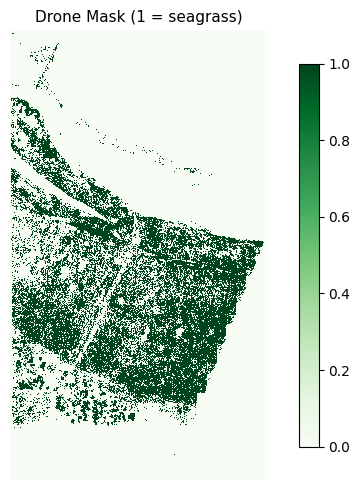

In [20]:
def bounds_to_wgs84(bounds, src_crs):
    """
    Reproject rasterio BoundingBox to WGS-84 (EPSG:4326).
    Returns (min_lon, min_lat, max_lon, max_lat).
    """
    from rasterio.warp import transform_bounds
    return transform_bounds(src_crs, 'EPSG:4326',
                            bounds.left, bounds.bottom,
                            bounds.right, bounds.top)


min_lon, min_lat, max_lon, max_lat = bounds_to_wgs84(drone_bounds, drone_crs)
print(f'AOI (WGS-84): ({min_lon:.6f}, {min_lat:.6f}) → ({max_lon:.6f}, {max_lat:.6f})')

# GEE geometry
aoi_ee = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat],
                                proj='EPSG:4326', geodesic=False)

# Quick visualisation
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(drone_mask, cmap='Greens', interpolation='nearest')
ax.set_title('Drone Mask (1 = seagrass)', fontsize=11)
ax.axis('off')
plt.colorbar(plt.cm.ScalarMappable(cmap='Greens'), ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

## Sentinel-2 Preprocessing (ACOLITE DSF)


In [33]:
# ── Cloud masking helpers  ────────────────────────

def mask_edges(image):
    return image.updateMask(
        image.select('B8A').mask().updateMask(image.select('B9').mask())
    )

def mask_clouds_s2cloudless(image):
    cloud_prob = ee.Image(image.get('cloud_mask')).select('probability')
    return image.updateMask(cloud_prob.lt(MAX_CLOUD_PROB))

def mask_clouds_csp(image):
    csp_mask = image.get('csp_mask')
    cs = ee.Algorithms.If(
        ee.Algorithms.IsEqual(csp_mask, None),
        ee.Image.constant(1),
        ee.Image(csp_mask).select('cs_cdf')
    )
    return image.updateMask(ee.Image(cs).gte(MAX_CLOUD_CSP))

def mask_shadows(image):
    nir   = image.select('B8')
    swir1 = image.select('B11')
    blue  = image.select('B2')
    is_dark      = nir.lt(1200)
    is_not_water = swir1.gt(150).Or(blue.divide(nir.add(0.001)).lt(1.5))
    potential_shadow = is_dark.And(is_not_water)
    cloud_mask_img = image.get('cloud_mask')
    cloud_for_proj = ee.Algorithms.If(
        ee.Algorithms.IsEqual(cloud_mask_img, None),
        ee.Image(image.get('csp_mask')).select('cs_cdf').lt(MAX_CLOUD_CSP).unmask(0),
        ee.Image(cloud_mask_img).select('probability').gt(MAX_CLOUD_PROB)
    )
    shadow_azimuth = ee.Number(90).subtract(
        ee.Number(image.get('MEAN_SOLAR_AZIMUTH_ANGLE'))
    )
    cloud_proj = (
        ee.Image(cloud_for_proj)
        .directionalDistanceTransform(shadow_azimuth, 10)
        .reproject(crs=image.select('B2').projection(), scale=30)
        .select('distance').mask()
    )
    return image.updateMask(potential_shadow.And(cloud_proj).Not())

def mask_to_aoi(image):
    mask = ee.Image.constant(1).clip(aoi_ee).mask()
    return image.updateMask(mask)

print('✓ Cloud-masking helpers defined')

✓ Cloud-masking helpers defined


In [35]:

def get_s2_l1c_collection(aoi_geom, start_date, end_date, max_cloud=30):
    """
    Return a dual-masked (s2cloudless + Cloud Score+) S2 L1C collection
    clipped to aoi_geom and scaled reflectance to [0, 1].
    """
    date_filter   = ee.Filter.date(start_date, end_date)
    bounds_filter = ee.Filter.bounds(aoi_geom)
    cloud_filter  = ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_cloud)

    # ── Base S2 L1C (filtered by AOI + date + loose cloud %) ────
    s2_l1c = (
        ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
        .filter(date_filter)
        .filter(bounds_filter)
        .filter(cloud_filter)
        .map(mask_edges)
    )
    n_base = s2_l1c.size().getInfo()
    print(f'  Stage 1 — S2 L1C scenes in date/bounds : {n_base}')
    if n_base == 0:
        raise RuntimeError(
            'No S2 scenes found.\n'
            f'  AOI   : {aoi_geom.bounds().getInfo()}\n'
            f'  Dates : {start_date} → {end_date}\n'
            'Verify the drone mask CRS and that the AOI is in the right location.'
        )

    # ── Join s2cloudless — secondary filtered by DATE ONLY ───────
    s2_clouds = (
        ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filter(date_filter)          # ← no bounds filter here
    )
    s2_joined = ee.ImageCollection(
        ee.Join.saveFirst('cloud_mask').apply(
            primary   = s2_l1c,
            secondary = s2_clouds,
            condition = ee.Filter.equals(
                leftField='system:index', rightField='system:index'
            ),
        )
    )
    n_joined = s2_joined.size().getInfo()
    print(f'  Stage 2 — after s2cloudless join        : {n_joined}')
    # If still 0 (s2cloudless simply absent for this region/period), fall back
    if n_joined == 0:
        print('  ⚠  s2cloudless join returned 0 — CSP will be the sole cloud mask')
        s2_joined = s2_l1c

    # ── Join Cloud Score+ — secondary filtered by DATE ONLY ──────
    s2_csp = (
        ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
        .filter(date_filter)          # ← no bounds filter here
    )
    s2_dual = ee.ImageCollection(
        ee.Join.saveFirst('csp_mask').apply(
            primary   = s2_joined,
            secondary = s2_csp,
            condition = ee.Filter.equals(
                leftField='system:index', rightField='system:index'
            ),
        )
    )
    n_dual = s2_dual.size().getInfo()
    print(f'  Stage 3 — after Cloud Score+ join       : {n_dual}')
    if n_dual == 0:
        print('  ⚠  CSP join returned 0 — proceeding without CSP masking')
        s2_dual = s2_joined

    # ── Per-pixel cloud/shadow masking — NO scaling ────────────────
    def apply_masks(img):
        img = mask_clouds_s2cloudless(img)
        img = mask_clouds_csp(img)
        img = mask_shadows(img)
        img = mask_to_aoi(img)
        return img.copyProperties(img, ['system:time_start', 'CLOUDY_PIXEL_PERCENTAGE'])

    cleaned = s2_dual.map(apply_masks)
    return cleaned


# ── Diagnostic: check raw scene count before calling ─────────────────────
print('=== Sentinel-2 Collection Query ===')
print(f'AOI bounds (WGS-84): ({min_lon:.5f}, {min_lat:.5f}) → ({max_lon:.5f}, {max_lat:.5f})')
print(f'Date range         : {S2_START_DATE} → {S2_END_DATE}')
print()

# Quick sanity check — raw unfiltered count
_raw = (
    ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
    .filter(ee.Filter.bounds(aoi_ee))
    .filter(ee.Filter.date(S2_START_DATE, S2_END_DATE))
)
print(f'Raw S2 scenes (no cloud filter): {_raw.size().getInfo()}')
print()

s2_collection = get_s2_l1c_collection(aoi_ee, S2_START_DATE, S2_END_DATE)
n_scenes = s2_collection.size().getInfo()
print(f'\n✓ Final collection size: {n_scenes} scenes')
if n_scenes == 0:
    raise RuntimeError(
        'Collection is still empty after all fallbacks.\n'
        'Try widening the date range or checking the AOI CRS.'
    )

=== Sentinel-2 Collection Query ===
AOI bounds (WGS-84): (124.05122, 10.23473) → (124.05288, 10.23758)
Date range         : 2025-01-01 → 2025-12-31

Raw S2 scenes (no cloud filter): 165

  Stage 1 — S2 L1C scenes in date/bounds : 31
  Stage 2 — after s2cloudless join        : 31
  Stage 3 — after Cloud Score+ join       : 31

✓ Final collection size: 31 scenes


## 7 · ACOLITE Atmospheric Correction + Water Quality Products

Apply ACOLITE DSF + deglinting to each scene, then add Chl-a (Mishra Red-Edge)
and turbidity / SPM (Nechad 2016) bands.

In [36]:

def correct_collection_with_acolite(collection):
    # Step 1: band selection, Rrs conversion, 10 m resampling (mappable server-side)
    collection_rrs = (
        collection
        .map(ACOLITE.select_sentinel2_bands)
        .map(ACOLITE.to_rrs)
        .map(ACOLITE.to_10m)
    )

    # Step 2: DSF + deglinting (requires Python loop — one GEE call per scene)
    collection_list = collection_rrs.toList(collection_rrs.size().getInfo())
    n = collection_list.size().getInfo()
    print(f'  Running DSF on {n} scenes...')

    corrected = []
    for i in tqdm(range(n), desc='ACOLITE DSF'):
        img = ee.Image(collection_list.get(i))
        try:
            img_dsf     = ACOLITE.dask_spectrum_fitting(img)
            img_deglint = ACOLITE.deglint_alternative(*img_dsf)
            corrected.append(img_deglint)
        except Exception as exc:
            sid = img.get('system:index').getInfo()
            print(f'    ⚠  skip {sid}: {exc}')

    print(f'  ✓ {len(corrected)} / {n} scenes corrected')
    if not corrected:
        raise RuntimeError('ACOLITE produced no valid scenes.')
    return ee.ImageCollection.fromImages(corrected)


def add_water_quality(collection):
    """Add Chl-a (Mishra Red-Edge) and turbidity/SPM (Nechad 2016) bands."""
    collection = collection.map(ACOLITE.add_chl_re_mishra)        # → 'chl_re_mishra'
    collection = collection.map(ACOLITE.add_spm_nechad2016_665)   # → 'spm_nechad2016_665'
    return collection


print('Applying ACOLITE DSF to all scenes (this may take a few minutes)...')
s2_corrected = correct_collection_with_acolite(s2_collection)
s2_with_wq   = add_water_quality(s2_corrected)
print(f'✓ ACOLITE + water quality complete  ({s2_corrected.size().getInfo()} scenes)')


Applying ACOLITE DSF to all scenes (this may take a few minutes)...
  Running DSF on 31 scenes...


ACOLITE DSF:   0%|          | 0/31 [00:00<?, ?it/s]

<---------------------------------------------------------------------------------------------------->
Pdark: {'B1': 0.11489999999999999, 'B2': 0.0848, 'B3': 0.07180478282088823, 'B4': 0.0406, 'B5': 0.0629, 'B6': 0.0605, 'B7': 0.0706, 'B8': 0.0505, 'B8A': 0.051939495798319316, 'B9': 0.006500000000000001, 'B10': 0.0025, 'B11': 0.012986768835753823, 'B12': 0.0058}
Geometry: sza=38.7747548826554, vza=10.248265420832938, raa=135.91273076702566
Gases: uwv=1.5, uoz=0.3, pressure=1013.25
Lut: sel_lut='ACOLITE-LUT-202110-MOD1', sel_aot=np.float64(0.369501154737394)
<---------------------------------------------------------------------------------------------------->
<---------------------------------------------------------------------------------------------------->
Pdark: {'B1': 0.1018, 'B2': 0.0729, 'B3': 0.06302205814490078, 'B4': 0.03475, 'B5': 0.0595, 'B6': 0.0563, 'B7': 0.0662, 'B8': 0.0478, 'B8A': 0.0425, 'B9': 0.008199999999999994, 'B10': 0.0010999999999999998, 'B11': 0.01112010140172

## One-Year Temporal Composite

Reduce the corrected collection to a **median composite** — robust against
residual clouds and sun-glint artefacts.

In [71]:
SPECTRAL_BANDS = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
WQ_BANDS       = ['chl_re_mishra', 'SPM_Nechad2016_665']   # exact names from ACOLITE
WQ_RENAME      = ['chlorophyll', 'turbidity']
ALL_BANDS      = SPECTRAL_BANDS + WQ_RENAME


def build_composite(collection_with_wq):
    """
    Build a median composite over all scenes.
    Selects spectral + WQ bands and renames WQ bands to friendly names.
    Returns an ee.Image clipped to the AOI.
    """
    collection_with_wq = collection_with_wq.map(lambda img: img.toFloat())
    # Verify actual band names from the first image (runs once, fast)
    first_bands = ee.Image(collection_with_wq.first()).bandNames().getInfo()
    print(f'  Bands in corrected collection: {first_bands}')

    # Select spectral bands (already named B1…B12)
    # Only keep bands that actually exist (some 60 m bands may be absent)
    available_spectral = [b for b in SPECTRAL_BANDS if b in first_bands]
    missing = [b for b in SPECTRAL_BANDS if b not in first_bands]
    if missing:
        print(f'  ⚠  Missing spectral bands (will be NaN): {missing}')

    # Identify WQ band names dynamically (handles capitalisation differences)
    chl_band  = next((b for b in first_bands if 'chl' in b.lower()), None)
    spm_band  = next((b for b in first_bands if 'spm' in b.lower() or 'turbidity' in b.lower()), None)

    wq_src    = [b for b in [chl_band, spm_band] if b is not None]
    wq_dst    = WQ_RENAME[:len(wq_src)]
    if not wq_src:
        print('  ⚠  No WQ bands found — chlorophyll and turbidity will be NaN')

    print(f'  WQ bands found: {list(zip(wq_src, wq_dst))}')

    # Build composite in two parts then add-bands
    spectral_composite = (
        collection_with_wq
        .select(available_spectral)
        .median()
        .clip(aoi_ee)
    )

    if wq_src:
        wq_composite = (
            collection_with_wq
            .select(wq_src, wq_dst)
            .median()
            .clip(aoi_ee)
        )
        composite = spectral_composite.addBands(wq_composite)
    else:
        composite = spectral_composite

    # Add any missing spectral bands as constant NaN so downstream code
    # always finds the expected band names
    for b in missing:
        composite = composite.addBands(
            ee.Image.constant(float('nan')).rename(b)
        )

    return composite


print('Building one-year median composite...')
composite = build_composite(s2_with_wq)
print('✓ Composite built')
print(f'  Final composite bands: {composite.bandNames().getInfo()}')

# Quick thumbnail
Map = geemap.Map()
Map.centerObject(aoi_ee, zoom=16)
Map.addLayer(composite.select(['B4','B3','B2']),
             {'min': 0, 'max': 0.05, 'gamma': 1.4}, 'S2 Composite RGB (Rrs)')
Map.addLayerControl()
Map

Building one-year median composite...
  Bands in corrected collection: ['constant', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12', 'chl_re_mishra', 'SPM_Nechad2016_665']
  WQ bands found: [('chl_re_mishra', 'chlorophyll'), ('SPM_Nechad2016_665', 'turbidity')]
✓ Composite built
  Final composite bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'chlorophyll', 'turbidity']


Map(center=[10.23615398087094, 124.05205162628202], controls=(WidgetControl(options=['position', 'transparent_…

In [72]:
def collection_to_xarray(ee_collection, ee_geom, crs='EPSG:4326', resolution=0.0001):

    ee_collection = ee_collection.toFloat()

    ds = xr.open_dataset(
        ee_collection,
        engine='ee',
        crs='EPSG:4326',
        scale=0.0001,
        geometry=ee_geom,
        chunks={'time': -1},
    )

    # Decode time if xee returned int64 ms-since-epoch
    if not np.issubdtype(ds.time.dtype, np.datetime64):
        decoded = pd.to_datetime(ds.time.values, unit='ms', utc=True).tz_localize(None)
        ds = ds.assign_coords(time=decoded)

    # xee with UTM uses uppercase X/Y — rename to lowercase
    da = ds.to_array(dim='band')           # (band, time, X, Y)
    da = da.transpose('time', 'band', 'lat', 'lon')   # Y=northing→y, X=easting→x
    da = da.rename({'lat': 'lat', 'lon': 'lon'})

    return da

ds_composite = collection_to_xarray(composite, aoi_ee)

## Build Sentinel-2 Resolution Grid

Create a regular grid whose cell size matches the Sentinel-2 pixel footprint
(~10 m). Each cell gets a centroid lat/lon.

In [74]:
def build_s2_grid(ds):
    """
    Build a DataFrame of grid cells directly from the composite xarray grid.
    Each row = one Sentinel-2 pixel.

    Returns
    -------
    grid_df : pd.DataFrame with columns [fid, lat, lon, row_idx, col_idx]
    lats     : 1-D lat array (descending, north → south)
    lons     : 1-D lon array (ascending, west → east)
    """
    lats = ds['lat'].values   # (nrows,)
    lons = ds['lon'].values   # (ncols,)

    lon_grid, lat_grid = np.meshgrid(lons, lats)   # (nrows, ncols)

    n_rows, n_cols = len(lats), len(lons)
    fids = np.arange(n_rows * n_cols)

    grid_df = pd.DataFrame({
        'fid'    : fids,
        'lat'    : lat_grid.ravel(),
        'lon'    : lon_grid.ravel(),
        'row_idx': np.repeat(np.arange(n_rows), n_cols),
        'col_idx': np.tile(np.arange(n_cols), n_rows),
    })

    print(f'Grid : {n_rows} rows × {n_cols} cols = {len(grid_df):,} cells')
    print(f'Lat  : {lats.min():.6f} → {lats.max():.6f}')
    print(f'Lon  : {lons.min():.6f} → {lons.max():.6f}')
    return grid_df, lats, lons


grid_df, s2_lats, s2_lons = build_s2_grid(ds_composite)
grid_df.head()

Grid : 29 rows × 17 cols = 493 cells
Lat  : 10.234778 → 10.237578
Lon  : 124.051274 → 124.052874


,fid,lat,lon,row_idx,col_idx
0,0,10.234778,124.051274,0,0
1,1,10.234778,124.051374,0,1
2,2,10.234778,124.051474,0,2
3,3,10.234778,124.051574,0,3
4,4,10.234778,124.051674,0,4


## Reproject Drone Mask to S2 Grid

Warp the high-resolution drone mask onto the Sentinel-2 pixel grid so that
each S2 cell accumulates the correct seagrass / non-seagrass pixel counts.

In [75]:
def reproject_drone_mask_to_s2_grid(drone_mask, drone_transform, drone_crs,
                                     s2_lats, s2_lons):
    """
    Reproject the drone binary mask to the S2 grid using nearest-neighbour
    resampling so class labels are preserved.

    Returns
    -------
    mask_on_s2 : (nrows, ncols) uint8 array aligned to the S2 grid
    s2_transform : rasterio Affine for the S2 grid
    """
    # S2 grid parameters
    n_rows = len(s2_lats)
    n_cols = len(s2_lons)

    dlat = abs(float(s2_lats[1] - s2_lats[0])) if n_rows > 1 else S2_RES_DEG
    dlon = abs(float(s2_lons[1] - s2_lons[0])) if n_cols > 1 else S2_RES_DEG

    # Top-left corner
    west  = float(s2_lons.min()) - dlon / 2
    north = float(s2_lats.max()) + dlat / 2
    s2_transform = from_origin(west, north, dlon, dlat)
    s2_crs = CRS.from_epsg(4326)

    mask_on_s2 = np.zeros((n_rows, n_cols), dtype=np.uint8)

    reproject(
        source            = drone_mask,
        destination       = mask_on_s2,
        src_transform     = drone_transform,
        src_crs           = drone_crs,
        dst_transform     = s2_transform,
        dst_crs           = s2_crs,
        resampling        = Resampling.nearest,
    )

    print(f'Reprojected mask shape : {mask_on_s2.shape}')
    print(f'Seagrass S2 pixels     : {mask_on_s2.sum():,} / {mask_on_s2.size:,}')
    return mask_on_s2, s2_transform


mask_s2, s2_transform = reproject_drone_mask_to_s2_grid(
    drone_mask, drone_transform, drone_crs, s2_lats, s2_lons
)

Reprojected mask shape : (29, 17)
Seagrass S2 pixels     : 118 / 493


## Compute Percent Cover per Grid Cell

Each Sentinel-2 cell maps to one pixel in `mask_s2` (after reprojection).
Percent cover = seagrass pixels / total valid pixels × 100.

> **Note**: because the drone mask and S2 grid are now co-registered at the
> same resolution, each S2 cell is exactly one pixel in `mask_s2`. The
> percent cover is therefore either 0 % or 100 % at this point. If you want
> a sub-pixel estimate, use a higher-resolution intermediate grid (see the
> `compute_subpixel_percent_cover` function below).

Computing sub-pixel percent cover (upsample ×10)...
Percent cover computed:
  Cells with any seagrass : 257 / 493
  Mean cover (non-zero)   : 43.5%


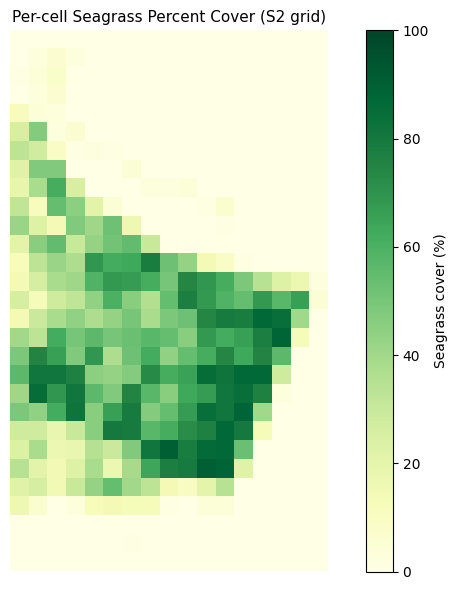

In [76]:
def compute_subpixel_percent_cover(drone_mask, drone_transform, drone_crs,
                                    s2_lats, s2_lons,
                                    upsample_factor: int = 10):
    """
    Compute per-S2-cell seagrass percent cover by counting original drone
    pixels that fall within each S2 cell (no spatial loss).

    Method
    ------
    1. Reproject the drone mask to a fine intermediate grid
       (S2 resolution / upsample_factor) using nearest-neighbour.
    2. Block-average the fine grid over (upsample_factor × upsample_factor)
       windows to get fractional cover per S2 cell.

    Parameters
    ----------
    upsample_factor : number of fine cells per S2 cell per axis.
                      10 → each S2 pixel is split into 10×10 = 100 sub-pixels.

    Returns
    -------
    percent_cover : (n_rows, n_cols) float32 in [0, 100]
    """
    n_rows = len(s2_lats)
    n_cols = len(s2_lons)
    dlat = abs(float(s2_lats[1] - s2_lats[0])) if n_rows > 1 else S2_RES_DEG
    dlon = abs(float(s2_lons[1] - s2_lons[0])) if n_cols > 1 else S2_RES_DEG

    # Fine grid
    fine_rows = n_rows * upsample_factor
    fine_cols = n_cols * upsample_factor
    fine_dlat = dlat / upsample_factor
    fine_dlon = dlon / upsample_factor

    west  = float(s2_lons.min()) - dlon / 2
    north = float(s2_lats.max()) + dlat / 2
    fine_transform = from_origin(west, north, fine_dlon, fine_dlat)

    fine_mask = np.zeros((fine_rows, fine_cols), dtype=np.uint8)
    reproject(
        source        = drone_mask,
        destination   = fine_mask,
        src_transform = drone_transform,
        src_crs       = drone_crs,
        dst_transform = fine_transform,
        dst_crs       = CRS.from_epsg(4326),
        resampling    = Resampling.nearest,
    )

    # Block-average over (upsample_factor × upsample_factor) windows
    f = upsample_factor
    # Crop to exact multiple
    fine_mask = fine_mask[:n_rows * f, :n_cols * f]
    reshaped  = fine_mask.reshape(n_rows, f, n_cols, f).astype(np.float32)
    percent_cover = reshaped.mean(axis=(1, 3)) * 100.0   # (n_rows, n_cols)

    n_seagrass = (percent_cover > 0).sum()
    print(f'Percent cover computed:')
    print(f'  Cells with any seagrass : {n_seagrass:,} / {percent_cover.size:,}')
    print(f'  Mean cover (non-zero)   : {percent_cover[percent_cover>0].mean():.1f}%')
    return percent_cover.astype(np.float32)


print('Computing sub-pixel percent cover (upsample ×10)...')
percent_cover_grid = compute_subpixel_percent_cover(
    drone_mask, drone_transform, drone_crs,
    s2_lats, s2_lons,
    upsample_factor=10
)

# Visualise
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(percent_cover_grid, cmap='YlGn', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Seagrass cover (%)')
ax.set_title('Per-cell Seagrass Percent Cover (S2 grid)', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

## Extract Spectral Reflectance per Grid Cell

In [77]:
def extract_spectral_bands(ds, spectral_bands=None):
    """
    Extract spectral reflectance from the composite xarray DataArray.
    ds is expected to have dims (time, band, lat, lon).
    """
    if spectral_bands is None:
        spectral_bands = SPECTRAL_BANDS
    spectral_arrays = {}
    n_rows, n_cols = len(s2_lats), len(s2_lons)

    # Get the actual band names present in the DataArray coordinate
    available_bands = ds.coords['band'].values.tolist()

    for band in spectral_bands:
        if band in available_bands:
            arr = ds.sel(band=band).values.astype(np.float32)  # (time, lat, lon) or (lat, lon)
            if arr.ndim == 3:
                arr = arr[0]  # take first time slice
            spectral_arrays[band] = arr
        else:
            print(f'  ⚠  Band {band} not in composite — filling with NaN')
            spectral_arrays[band] = np.full((n_rows, n_cols), np.nan, dtype=np.float32)

    print(f'✓ Extracted {len(spectral_arrays)} spectral bands')
    return spectral_arrays


def extract_water_quality(ds):
    """
    Extract chlorophyll and turbidity from the composite DataArray.
    ds is expected to have dims (time, band, lat, lon).
    """
    n_rows, n_cols = len(s2_lats), len(s2_lons)
    wq_arrays = {}

    available_bands = ds.coords['band'].values.tolist()

    for friendly in WQ_RENAME:  # ['chlorophyll', 'turbidity']
        if friendly in available_bands:
            arr = ds.sel(band=friendly).values.astype(np.float32)
            if arr.ndim == 3:
                arr = arr[0]
            wq_arrays[friendly] = arr
        else:
            print(f'  ⚠  {friendly} not found in composite — filling with NaN')
            wq_arrays[friendly] = np.full((n_rows, n_cols), np.nan, dtype=np.float32)

    return wq_arrays


spectral_arrays = extract_spectral_bands(ds_composite)
wq_arrays       = extract_water_quality(ds_composite)
print('✓ Spectral + water-quality extraction complete')

✓ Extracted 11 spectral bands
✓ Spectral + water-quality extraction complete


## Estimate Bathymetry (PINN)

In [78]:
# Load the PINN bathymetry model
infer = load_bathymetry_model(
    model_dir  = MODEL_DIR,
    depth_min  = 0.0,
    depth_max  = 30.0,
    batch_size = 2048,
    verbose    = True,
)
print('✓ PINN model loaded')

✓ Physics parameters loaded:
    k    = 0.956643
    R0   = 0.812017
    Rinf = 0.113857

Building PINN model skeleton...
✓ Weights restored from: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/pinn_weights.weights.h5
  k    max_diff = 3.25e-01
  R0   max_diff = 4.04e-01
  Rinf max_diff = 1.49e-08
⚠  No scaler found — inputs must already be normalised.

MODEL READY FOR INFERENCE
  Usage : infer.predict_xarray(scene_da)
       or infer.predict_array(array)  — (n_pixels, 8)
  Bands : ['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']
  Depth : 0.0 – 30.0 m
✓ PINN model loaded


✓ Bathymetry estimated
  Valid pixels: 398 / 493
  Depth range : 0.65 – 3.86 m


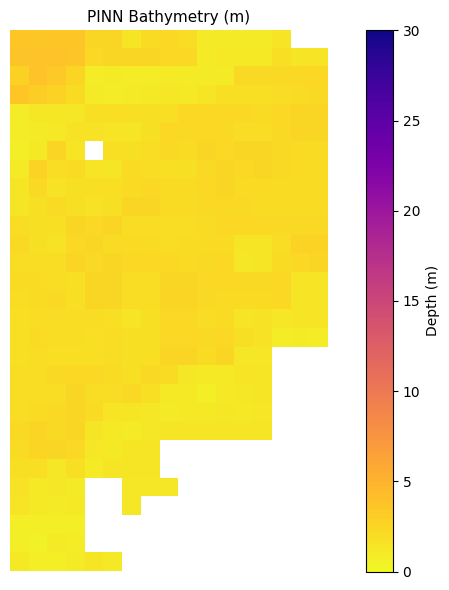

In [79]:
def estimate_bathymetry(spectral_arrays, infer, expected_bands=EXPECTED_BANDS):
    """
    Run the PINN bathymetry model on the composite spectral reflectance.

    Parameters
    ----------
    spectral_arrays : dict of {band_name: (n_rows, n_cols) array}
    infer           : BathymetryInference object
    expected_bands  : ordered list of band names the PINN expects

    Returns
    -------
    depth_grid : (n_rows, n_cols) float32 array of estimated depth in metres
    """
    n_rows, n_cols = spectral_arrays[list(spectral_arrays.keys())[0]].shape

    # Stack bands in PINN order → (n_pixels, n_bands)
    band_stack = []
    for b in expected_bands:
        if b in spectral_arrays:
            band_stack.append(spectral_arrays[b].ravel())
        else:
            print(f'  ⚠  PINN band {b} missing — filling with 0')
            band_stack.append(np.zeros(n_rows * n_cols, dtype=np.float32))

    pixel_matrix = np.stack(band_stack, axis=1).astype(np.float32)   # (N, B)

    # Mask out NaN pixels (PINN cannot handle them)
    valid_mask   = np.isfinite(pixel_matrix).all(axis=1)
    depths_flat  = np.full(n_rows * n_cols, np.nan, dtype=np.float32)

    if valid_mask.sum() > 0:
        depths_flat[valid_mask] = infer.predict_array(
            pixel_matrix[valid_mask]
        ).astype(np.float32)

    depth_grid = depths_flat.reshape(n_rows, n_cols)
    valid_depths = depth_grid[np.isfinite(depth_grid)]
    print(f'✓ Bathymetry estimated')
    print(f'  Valid pixels: {valid_mask.sum():,} / {len(valid_mask):,}')
    print(f'  Depth range : {valid_depths.min():.2f} – {valid_depths.max():.2f} m')
    return depth_grid


depth_grid = estimate_bathymetry(spectral_arrays, infer)

# Visualise
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(depth_grid, cmap='plasma_r', vmin=0, vmax=30)
plt.colorbar(im, ax=ax, label='Depth (m)')
ax.set_title('PINN Bathymetry (m)', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

## Assemble & Export CSV

Join all extracted attributes into a single flat DataFrame and write to CSV.

In [90]:
def assemble_csv(grid_df,
                 percent_cover_grid,
                 spectral_arrays,
                 wq_arrays,
                 depth_grid,
                 min_valid_frac: float = MIN_VALID_FRAC,
                 output_path: str = OUTPUT_CSV):
    n_rows = len(s2_lats)
    n_cols = len(s2_lons)

    df = grid_df[['fid', 'lat', 'lon']].copy()
    df['percent_cover'] = percent_cover_grid.ravel()

    for band in SPECTRAL_BANDS:
        df[band] = spectral_arrays[band].ravel()

    for wq in WQ_RENAME:                    # ← was WQ_BANDS
        df[wq] = wq_arrays[wq].ravel()

    df['depth'] = depth_grid.ravel()

    spectral_cols = SPECTRAL_BANDS
    valid_mask = df[spectral_cols].notna().any(axis=1)
    df_out = df[valid_mask].reset_index(drop=True)
    df_out['fid'] = df_out.index

    df_out['lat']           = df_out['lat'].round(8)
    df_out['lon']           = df_out['lon'].round(8)
    df_out['percent_cover'] = df_out['percent_cover'].round(2)
    for b in SPECTRAL_BANDS:
        df_out[b] = df_out[b].round(6)
    df_out['chlorophyll']   = df_out['chlorophyll'].round(4)
    df_out['turbidity']     = df_out['turbidity'].round(4)
    df_out['depth']         = df_out['depth'].round(3)

    cols = ['fid', 'lat', 'lon', 'percent_cover'] + SPECTRAL_BANDS + WQ_RENAME + ['depth']  # ← was WQ_BANDS
    df_out = df_out[cols]

    df_out.to_csv(output_path, index=False)
    print(f'✓ CSV saved → {output_path}')
    print(f'  Rows      : {len(df_out):,}')
    print(f'  Columns   : {list(df_out.columns)}')
    print(f'\nSample:')
    return df_out

df_result = assemble_csv(
    grid_df,
    percent_cover_grid,
    spectral_arrays,
    wq_arrays,
    depth_grid,
    output_path=OUTPUT_CSV
)
df_result.head(10)

✓ CSV saved → /content/drive/MyDrive/BlueCARES_Seagrass/regression/seagrass_percent_cover.csv
  Rows      : 493
  Columns   : ['fid', 'lat', 'lon', 'percent_cover', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'chlorophyll', 'turbidity', 'depth']

Sample:


,fid,lat,lon,percent_cover,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,chlorophyll,turbidity,depth
0,0,10.234778,124.051274,0.0,0.118624,0.183731,0.258504,0.248596,0.260767,0.228613,0.248943,0.249781,0.240353,0.156763,0.127403,16.178301,-185.803207,3.592
1,1,10.234778,124.051374,0.0,0.118624,0.185603,0.256209,0.256704,0.228500,0.224263,0.244532,0.239317,0.226342,0.138134,0.118475,12.293000,-192.263107,3.513
2,2,10.234778,124.051474,0.0,0.118348,0.181294,0.248697,0.238675,0.225784,0.198930,0.215738,0.185285,0.186475,0.134863,0.113459,16.101299,-206.457901,3.628
3,3,10.234778,124.051574,0.0,0.118304,0.169656,0.238460,0.207269,0.193309,0.165924,0.179246,0.167932,0.167321,0.128727,0.123632,13.784700,-208.268799,3.564
4,4,10.234778,124.051674,0.0,0.091642,0.158042,0.210932,0.207598,0.191318,0.154827,0.178302,0.174751,0.134490,0.125463,0.108852,11.599000,-206.659698,2.399
5,5,10.234778,124.051774,0.0,0.089187,0.150890,0.198267,0.190310,0.185534,0.140593,0.156005,0.146289,0.130401,0.117464,0.105725,14.319800,37.605999,2.559
6,6,10.234778,124.051874,0.0,0.082429,0.139515,0.194042,0.187569,0.173601,0.122140,0.138643,0.142614,0.118860,0.110033,0.096779,11.655700,44.339600,1.403
7,7,10.234778,124.051974,0.0,0.082429,0.138569,0.187525,0.171749,0.173601,0.122140,0.138643,0.136500,0.118860,0.110033,0.096779,13.478600,37.618999,2.100
8,8,10.234778,124.052074,0.0,0.078041,0.115181,0.166742,0.149272,0.166323,0.114411,0.130010,0.132226,0.120605,0.106322,0.093457,13.986600,60.069199,2.332
9,9,10.234778,124.052174,0.0,0.078041,0.121534,0.169700,0.139898,0.167755,0.123359,0.135691,0.140639,0.129001,0.127468,0.094495,14.538600,53.634899,1.965


In [91]:
# ── Summary statistics ────────────────────────────────────────────────────
print('=== SEAGRASS PERCENT COVER SUMMARY ===')
print(df_result[['percent_cover','depth','chlorophyll','turbidity']].describe().round(3).to_string())

seagrass_cells = (df_result['percent_cover'] > 0).sum()
print(f'\nTotal cells       : {len(df_result):,}')
print(f'Cells w/ seagrass : {seagrass_cells:,} ({100*seagrass_cells/len(df_result):.1f}%)')
print(f'Mean cover (>0)   : {df_result.loc[df_result.percent_cover>0,"percent_cover"].mean():.1f}%')

=== SEAGRASS PERCENT COVER SUMMARY ===
       percent_cover    depth  chlorophyll  turbidity
count        493.000  398.000      418.000    418.000
mean          22.665    1.843       32.157     11.941
std           28.725    0.579       38.054     51.849
min            0.000    0.653        6.526   -244.162
25%            0.000    1.349       15.320     11.540
50%            2.000    1.933       20.531     14.027
75%           46.000    2.203       30.500     23.348
max           90.000    3.860      246.746    124.526

Total cells       : 493
Cells w/ seagrass : 257 (52.1%)
Mean cover (>0)   : 43.5%


## Visualization

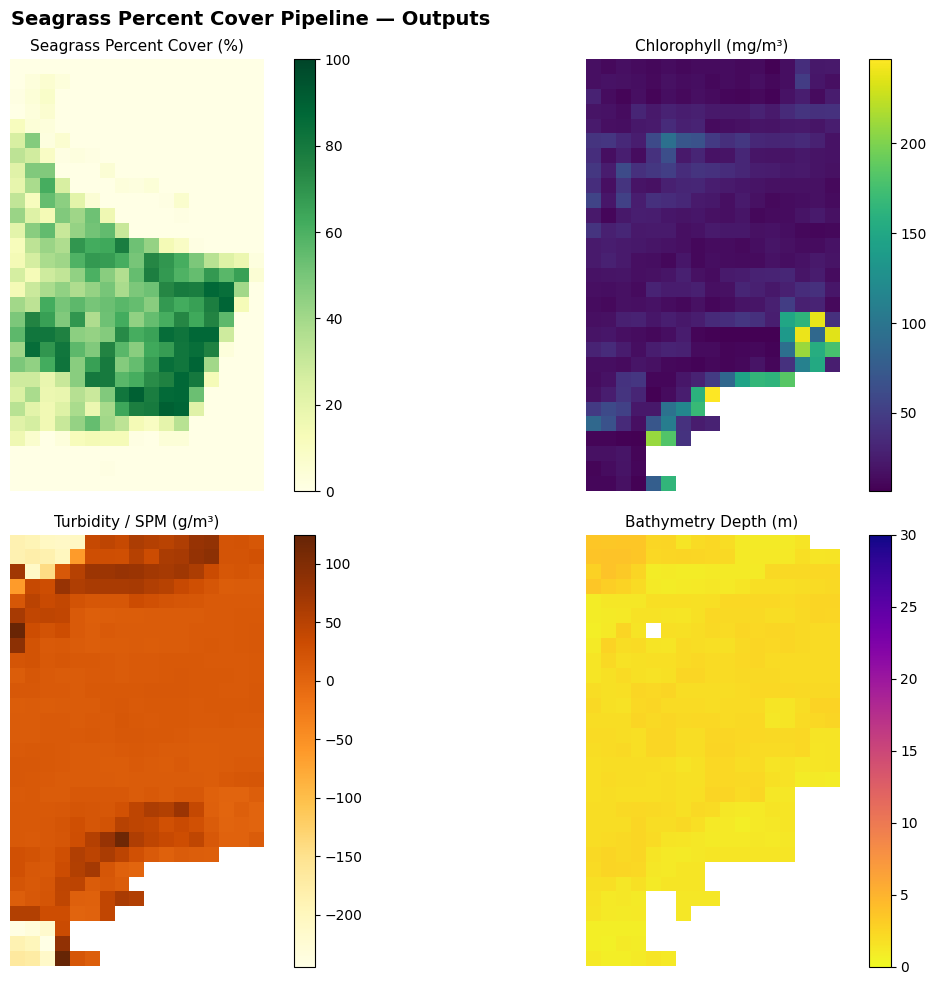

✓ Overview figure saved


In [92]:
# ── 4-panel visualisation ─────────────────────────────────────────────────
n_rows_grid = len(s2_lats)
n_cols_grid = len(s2_lons)

pc_grid  = df_result.set_index(['row_idx','col_idx'])['percent_cover'] \
    if 'row_idx' in df_result.columns else percent_cover_grid
chl_img  = wq_arrays['chlorophyll']
turb_img = wq_arrays['turbidity']
dep_img  = depth_grid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

panels = [
    (percent_cover_grid, 'YlGn',    0,  100, 'Seagrass Percent Cover (%)'),
    (chl_img,            'viridis', None, None, 'Chlorophyll (mg/m³)'),
    (turb_img,           'YlOrBr',  None, None, 'Turbidity / SPM (g/m³)'),
    (dep_img,            'plasma_r', 0,  30,  'Bathymetry Depth (m)'),
]

for ax, (data, cmap, vmin, vmax, title) in zip(axes.ravel(), panels):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, origin='upper', aspect='equal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

fig.suptitle('Seagrass Percent Cover Pipeline — Outputs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_CSV.replace('.csv', '_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Overview figure saved')

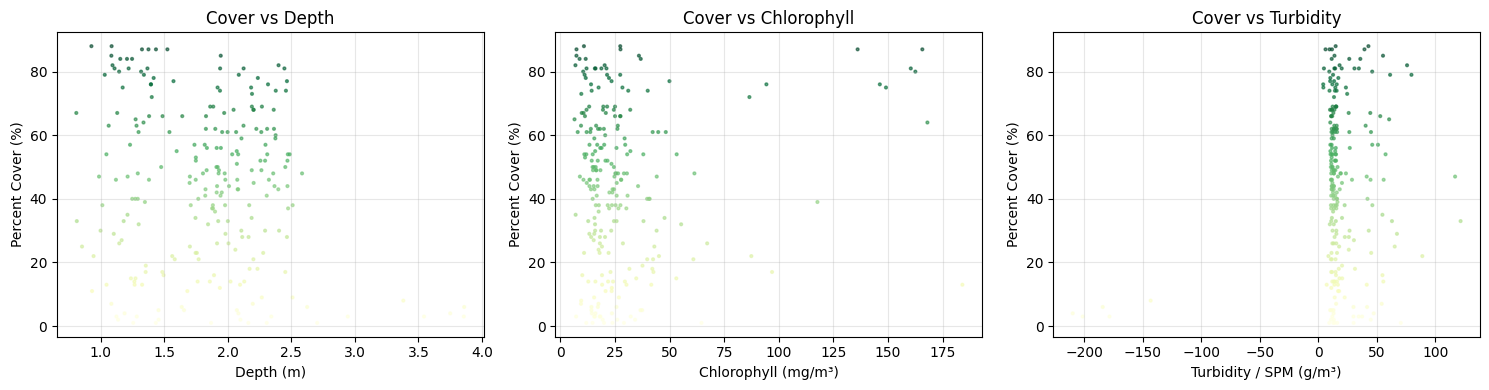


[DONE] Pipeline complete.  CSV at: /content/drive/MyDrive/BlueCARES_Seagrass/regression/seagrass_percent_cover.csv


In [93]:
# ── Scatter: percent cover vs depth ──────────────────────────────────────
sub = df_result[(df_result['percent_cover'] > 0) & df_result['depth'].notna()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(sub['depth'], sub['percent_cover'],
                c=sub['percent_cover'], cmap='YlGn', s=4, alpha=0.6)
axes[0].set_xlabel('Depth (m)');  axes[0].set_ylabel('Percent Cover (%)')
axes[0].set_title('Cover vs Depth')

axes[1].scatter(sub['chlorophyll'], sub['percent_cover'],
                c=sub['percent_cover'], cmap='YlGn', s=4, alpha=0.6)
axes[1].set_xlabel('Chlorophyll (mg/m³)'); axes[1].set_ylabel('Percent Cover (%)')
axes[1].set_title('Cover vs Chlorophyll')

axes[2].scatter(sub['turbidity'], sub['percent_cover'],
                c=sub['percent_cover'], cmap='YlGn', s=4, alpha=0.6)
axes[2].set_xlabel('Turbidity / SPM (g/m³)'); axes[2].set_ylabel('Percent Cover (%)')
axes[2].set_title('Cover vs Turbidity')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_CSV.replace('.csv', '_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\n[DONE] Pipeline complete.  CSV at: {OUTPUT_CSV}')